In [1229]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as special
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import r2_score
import pandas as pd

In [1230]:
data_sucio = pd.read_csv('DataAnalytics.csv')
data_sucio.head(5)

,Administrador,Usuario,botón correcto,tiempo de interacción,mini juego,número de interacción,color presionado,dificultad,fecha,Juego,auto push,tiempo de lección,tiempo de sesión
0,nicolas,nicolas,1.0,5.399169,Despegue,1.0,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro,0.0,0.0,0.0
1,nicolas,nicolas,0.0,1.283400,Despegue,2.0,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro,0.0,0.0,0.0
2,nicolas,nicolas,1.0,2.700226,Despegue,3.0,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro,0.0,0.0,0.0
3,nicolas,nicolas,0.0,3.050262,Despegue,4.0,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro,0.0,0.0,0.0
4,nicolas,nicolas,0.0,4.750256,Despegue,5.0,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro,0.0,0.0,0.0


In [1231]:
data_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5865 entries, 0 to 5864
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Administrador          5865 non-null   object 
 1   Usuario                5865 non-null   object 
 2   botón correcto         5103 non-null   float64
 3   tiempo de interacción  5103 non-null   float64
 4   mini juego             5709 non-null   object 
 5   número de interacción  5103 non-null   float64
 6   color presionado       5103 non-null   object 
 7   dificultad             5865 non-null   object 
 8   fecha                  5865 non-null   object 
 9   Juego                  5865 non-null   object 
 10  auto push              5103 non-null   float64
 11  tiempo de lección      5688 non-null   float64
 12  tiempo de sesión       5259 non-null   float64
dtypes: float64(6), object(7)
memory usage: 595.8+ KB


## Limpieza de Datos Nulos

In [1232]:
data_cuanti=data_sucio.select_dtypes(include=["float64","int64","float","int"])
data_cuali=data_sucio.select_dtypes(include=["object","datetime","category","datetime64[ns]"])
data_cuali.info()
data_cuanti.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5865 entries, 0 to 5864
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Administrador     5865 non-null   object
 1   Usuario           5865 non-null   object
 2   mini juego        5709 non-null   object
 3   color presionado  5103 non-null   object
 4   dificultad        5865 non-null   object
 5   fecha             5865 non-null   object
 6   Juego             5865 non-null   object
dtypes: object(7)
memory usage: 320.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5865 entries, 0 to 5864
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   botón correcto         5103 non-null   float64
 1   tiempo de interacción  5103 non-null   float64
 2   número de interacción  5103 non-null   float64
 3   auto push              5103 non-null   float64
 4   tiempo de lecci

In [1233]:
cualis_bfill=data_cuali.fillna(method="bfill")
cualis_ffill=data_cuali.fillna(method="ffill")
cuantias_mean=data_cuanti.fillna(round(data_cuanti.mean(),1))

data_sin_nulos = pd.concat([cuantias_mean,cualis_ffill],axis=1)

data_sin_nulos

C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\1919879999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cualis_bfill=data_cuali.fillna(method="bfill")
C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\1919879999.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cualis_ffill=data_cuali.fillna(method="ffill")


,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego
0,1.0,5.399169,1.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro
1,0.0,1.283400,2.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro
2,1.0,2.700226,3.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro
3,0.0,3.050262,4.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro
4,0.0,4.750256,5.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,0.0,6.300000,332.240000,ALEIDA,ESMERALDA,Restaurante,green,Episodio 1,28/05/2024 04:15:49 p. m.,Astro
5861,0.0,2.135419,1.0,0.0,0.000000,0.000000,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:54 a. m.,Astro
5862,0.5,10.000000,13.3,0.0,2.271806,12.400000,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro
5863,0.5,10.000000,13.3,0.0,6.300000,6.478299,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro


In [1234]:
data=data_sin_nulos.isnull().sum().sum()
print(data)

0


In [1235]:
DATA = data

## Limpieza de Outliers

In [1236]:
cuantitativas=data_sucio.select_dtypes(include=["float64","int64","float","int"])
cualitativas=data_sucio.select_dtypes(include=["object","datetime","category"])
y=cuantitativas

percentile25=y.quantile(0.25)
percentile75=y.quantile(0.75)
iqr= percentile75-percentile25

Limite_Superior_iqr= percentile75+1.5*iqr
Limite_Inferior_iqr= percentile25-1.5*iqr
iqr=cuantitativas[(y<=Limite_Superior_iqr)&y>=(Limite_Inferior_iqr)]
iqr2=iqr.fillna(round(iqr.mean(),1))
rango_intercuartilico=pd.concat([cualitativas,iqr2],axis=1)
rango_intercuartilico

,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión
0,nicolas,nicolas,Despegue,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro,1.0,5.399169,1.0,0.0,0.000000,0.000000
1,nicolas,nicolas,Despegue,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro,0.0,1.283400,2.0,0.0,0.000000,0.000000
2,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro,1.0,2.700226,3.0,0.0,0.000000,0.000000
3,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro,0.0,3.050262,4.0,0.0,0.000000,0.000000
4,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro,0.0,4.750256,5.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,ALEIDA,ESMERALDA,NaN,NaN,Episodio 1,28/05/2024 04:15:49 p. m.,Astro,0.5,10.000000,13.3,0.0,6.300000,332.240000
5861,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:54 a. m.,Astro,0.0,2.135419,1.0,0.0,0.000000,0.000000
5862,ALEIDA,JOSE JAVIER,Asteroides,NaN,Episodio 3,04/06/2024 11:09:58 a. m.,Astro,0.5,10.000000,13.3,0.0,2.271806,12.400000
5863,ALEIDA,JOSE JAVIER,NaN,NaN,Episodio 3,04/06/2024 11:09:58 a. m.,Astro,0.5,10.000000,13.3,0.0,6.300000,6.478299


In [1237]:
cualis_bfill=data_cuali.fillna(method="bfill")
cualis_ffill=data_cuali.fillna(method="ffill")
cuantias_mean=data_cuanti.fillna(round(data_cuanti.mean(),1))

data = pd.concat([cuantias_mean,cualis_ffill],axis=1)

data

C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\3597238304.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cualis_bfill=data_cuali.fillna(method="bfill")
C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\3597238304.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cualis_ffill=data_cuali.fillna(method="ffill")


,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego
0,1.0,5.399169,1.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro
1,0.0,1.283400,2.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro
2,1.0,2.700226,3.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro
3,0.0,3.050262,4.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro
4,0.0,4.750256,5.0,0.0,0.000000,0.000000,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,0.0,6.300000,332.240000,ALEIDA,ESMERALDA,Restaurante,green,Episodio 1,28/05/2024 04:15:49 p. m.,Astro
5861,0.0,2.135419,1.0,0.0,0.000000,0.000000,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:54 a. m.,Astro
5862,0.5,10.000000,13.3,0.0,2.271806,12.400000,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro
5863,0.5,10.000000,13.3,0.0,6.300000,6.478299,ALEIDA,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro


In [1238]:
outliers_limpios=data.isnull().sum().sum()
print(outliers_limpios)

0


In [1239]:
#Administrador
frecuencia_ad = data["Administrador"].value_counts().reset_index()
frecuencia_ad.columns = ["Administrador", "Frecuencia"]
frecuencia_ad

,Administrador,Frecuencia
0,ALEIDA,3260
1,nicolas,440
2,LEONARDO,371
3,DENISSE,302
4,SERGIO ANGEL,243
5,CARLOS ENRIQUE,228
6,YAEL DAVID,224
7,AUSTIN,199
8,VALENTIN,163
9,erick,158


In [1240]:
data["Administrador"]=data["Administrador"].str.replace("ALEIDA","1")
data["Administrador"]=data["Administrador"].str.replace("nicolas","2")
data["Administrador"]=data["Administrador"].str.replace("LEONARDO","3")
data["Administrador"]=data["Administrador"].str.replace("DENISSE","4")
data["Administrador"]=data["Administrador"].str.replace("SERGIO ANGEL","5")
data["Administrador"]=data["Administrador"].str.replace("CARLOS ENRIQUE","6")
data["Administrador"]=data["Administrador"].str.replace("YAEL DAVID","7")
data["Administrador"]=data["Administrador"].str.replace("AUSTIN","8")
data["Administrador"]=data["Administrador"].str.replace("VALENTIN","9")
data["Administrador"]=data["Administrador"].str.replace("erick","10")
data["Administrador"]=data["Administrador"].str.replace("IKER BENJAMIN","11")
data["Administrador"]=data["Administrador"].str.replace("KYTZIA","12")
data["Administrador"]=data["Administrador"].str.replace("BENJAMIN","13")
data

,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego
0,1.0,5.399169,1.0,0.0,0.000000,0.000000,2,nicolas,Despegue,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro
1,0.0,1.283400,2.0,0.0,0.000000,0.000000,2,nicolas,Despegue,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro
2,1.0,2.700226,3.0,0.0,0.000000,0.000000,2,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro
3,0.0,3.050262,4.0,0.0,0.000000,0.000000,2,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro
4,0.0,4.750256,5.0,0.0,0.000000,0.000000,2,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,0.0,6.300000,332.240000,1,ESMERALDA,Restaurante,green,Episodio 1,28/05/2024 04:15:49 p. m.,Astro
5861,0.0,2.135419,1.0,0.0,0.000000,0.000000,1,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:54 a. m.,Astro
5862,0.5,10.000000,13.3,0.0,2.271806,12.400000,1,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro
5863,0.5,10.000000,13.3,0.0,6.300000,6.478299,1,JOSE JAVIER,Asteroides,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro


In [1241]:
#Usuario
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
frecuencia_us = data["Usuario"].value_counts().reset_index()
frecuencia_us.columns = ["Usuario", "Frecuencia"]
frecuencia_us

,Usuario,Frecuencia
0,LEONARDO,546
1,ALEIDA,487
2,nicolas,440
3,JOSE JAVIER,394
4,LEONARDO,371
5,JESUS ALEJANDRO,356
6,ramiro isai,332
7,ADRIAN,280
8,SERGIO ANGEL,243
9,DENISSE,228


In [1242]:
#Mini juego
frecuencia_mj = data["mini juego"].value_counts().reset_index()
frecuencia_mj.columns = ["mini juego", "Frecuencia"]
frecuencia_mj

,mini juego,Frecuencia
0,Asteroides,1088
1,Restaurante,888
2,Estrellas,837
3,Gusanos,768
4,sonidos y animales,765
5,animales y colores,563
6,figuras y colores,409
7,partes del cuerpo,329
8,Despegue,197
9,MiniGame_0,8


In [1243]:
data["mini juego"]=data["mini juego"].str.replace("Asteroides","1")
data["mini juego"]=data["mini juego"].str.replace("Restaurante","2")
data["mini juego"]=data["mini juego"].str.replace("Estrellas","3")
data["mini juego"]=data["mini juego"].str.replace("Gusanos","4")
data["mini juego"]=data["mini juego"].str.replace("sonidos y animales","5")
data["mini juego"]=data["mini juego"].str.replace("animales y colores","6")
data["mini juego"]=data["mini juego"].str.replace("figuras y colores","7")
data["mini juego"]=data["mini juego"].str.replace("partes del cuerpo","8")
data["mini juego"]=data["mini juego"].str.replace("Despegue","9")
data["mini juego"]=data["mini juego"].str.replace("MiniGame_0","10")
data["mini juego"]=data["mini juego"].str.replace("MiniGame_3","11")
data["mini juego"]=data["mini juego"].str.replace("MiniGame_2","12")
data["mini juego"]=data["mini juego"].str.replace("MiniGame_1","13")
data

,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego
0,1.0,5.399169,1.0,0.0,0.000000,0.000000,2,nicolas,9,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro
1,0.0,1.283400,2.0,0.0,0.000000,0.000000,2,nicolas,9,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro
2,1.0,2.700226,3.0,0.0,0.000000,0.000000,2,nicolas,9,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro
3,0.0,3.050262,4.0,0.0,0.000000,0.000000,2,nicolas,9,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro
4,0.0,4.750256,5.0,0.0,0.000000,0.000000,2,nicolas,9,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,0.0,6.300000,332.240000,1,ESMERALDA,2,green,Episodio 1,28/05/2024 04:15:49 p. m.,Astro
5861,0.0,2.135419,1.0,0.0,0.000000,0.000000,1,JOSE JAVIER,1,green,Episodio 3,04/06/2024 11:09:54 a. m.,Astro
5862,0.5,10.000000,13.3,0.0,2.271806,12.400000,1,JOSE JAVIER,1,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro
5863,0.5,10.000000,13.3,0.0,6.300000,6.478299,1,JOSE JAVIER,1,green,Episodio 3,04/06/2024 11:09:58 a. m.,Astro


In [1244]:
#Color presionado
frecuencia_co = data["color presionado"].value_counts().reset_index()
frecuencia_co.columns = ["color presionado", "Frecuencia"]
frecuencia_co

,color presionado,Frecuencia
0,violet,1609
1,green,1455
2,yellow,1425
3,blue,1342
4,red,34


In [1245]:
data["color presionado"]=data["color presionado"].str.replace("violet","1")
data["color presionado"]=data["color presionado"].str.replace("green","2")
data["color presionado"]=data["color presionado"].str.replace("yellow","3")
data["color presionado"]=data["color presionado"].str.replace("blue","4")
data["color presionado"]=data["color presionado"].str.replace("red","5")
data

,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego
0,1.0,5.399169,1.0,0.0,0.000000,0.000000,2,nicolas,9,4,Episodio 1,25/01/2024 09:26:42 a. m.,Astro
1,0.0,1.283400,2.0,0.0,0.000000,0.000000,2,nicolas,9,1,Episodio 1,25/01/2024 09:26:46 a. m.,Astro
2,1.0,2.700226,3.0,0.0,0.000000,0.000000,2,nicolas,9,2,Episodio 1,25/01/2024 09:26:48 a. m.,Astro
3,0.0,3.050262,4.0,0.0,0.000000,0.000000,2,nicolas,9,2,Episodio 1,25/01/2024 09:26:57 a. m.,Astro
4,0.0,4.750256,5.0,0.0,0.000000,0.000000,2,nicolas,9,2,Episodio 1,25/01/2024 09:26:58 a. m.,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,0.0,6.300000,332.240000,1,ESMERALDA,2,2,Episodio 1,28/05/2024 04:15:49 p. m.,Astro
5861,0.0,2.135419,1.0,0.0,0.000000,0.000000,1,JOSE JAVIER,1,2,Episodio 3,04/06/2024 11:09:54 a. m.,Astro
5862,0.5,10.000000,13.3,0.0,2.271806,12.400000,1,JOSE JAVIER,1,2,Episodio 3,04/06/2024 11:09:58 a. m.,Astro
5863,0.5,10.000000,13.3,0.0,6.300000,6.478299,1,JOSE JAVIER,1,2,Episodio 3,04/06/2024 11:09:58 a. m.,Astro


In [1246]:
#Dificultad
frecuencia_di = data["dificultad"].value_counts().reset_index()
frecuencia_di.columns = ["dificultad", "Frecuencia"]
frecuencia_di

,dificultad,Frecuencia
0,Episodio 1,2357
1,Episodio 2,1493
2,Episodio 3,1292
3,Episodio 4,723


In [1247]:
data["dificultad"]=data["dificultad"].str.replace("Episodio 1","1")
data["dificultad"]=data["dificultad"].str.replace("Episodio 2","2")
data["dificultad"]=data["dificultad"].str.replace("Episodio 3","3")
data["dificultad"]=data["dificultad"].str.replace("Episodio 4","4")
data

,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego
0,1.0,5.399169,1.0,0.0,0.000000,0.000000,2,nicolas,9,4,1,25/01/2024 09:26:42 a. m.,Astro
1,0.0,1.283400,2.0,0.0,0.000000,0.000000,2,nicolas,9,1,1,25/01/2024 09:26:46 a. m.,Astro
2,1.0,2.700226,3.0,0.0,0.000000,0.000000,2,nicolas,9,2,1,25/01/2024 09:26:48 a. m.,Astro
3,0.0,3.050262,4.0,0.0,0.000000,0.000000,2,nicolas,9,2,1,25/01/2024 09:26:57 a. m.,Astro
4,0.0,4.750256,5.0,0.0,0.000000,0.000000,2,nicolas,9,2,1,25/01/2024 09:26:58 a. m.,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,0.0,6.300000,332.240000,1,ESMERALDA,2,2,1,28/05/2024 04:15:49 p. m.,Astro
5861,0.0,2.135419,1.0,0.0,0.000000,0.000000,1,JOSE JAVIER,1,2,3,04/06/2024 11:09:54 a. m.,Astro
5862,0.5,10.000000,13.3,0.0,2.271806,12.400000,1,JOSE JAVIER,1,2,3,04/06/2024 11:09:58 a. m.,Astro
5863,0.5,10.000000,13.3,0.0,6.300000,6.478299,1,JOSE JAVIER,1,2,3,04/06/2024 11:09:58 a. m.,Astro


In [1248]:
#Juego
frecuencia_ju = data["Juego"].value_counts().reset_index()
frecuencia_ju.columns = ["Juego", "Frecuencia"]
frecuencia_ju

,Juego,Frecuencia
0,Astro,3799
1,Cadetes,2066


## Analizar las correlaciones lineales simples (“Heatmap”) que tiene la columna “Color Presionado”

In [1249]:
data=data.drop(["fecha"],axis=1)
data=data.drop(["auto push"],axis=1)

In [1250]:
df_numeric = data.select_dtypes(include=["float64","int64","float","int"])
matriz_corr = df_numeric.corr()
matriz_corr

,botón correcto,tiempo de interacción,número de interacción,tiempo de lección,tiempo de sesión
botón correcto,1.000000,-0.128073,-0.242192,0.003439,0.001687
tiempo de interacción,-0.128073,1.000000,0.568847,0.000198,0.000097
número de interacción,-0.242192,0.568847,1.000000,-0.000280,-0.000138
tiempo de lección,0.003439,0.000198,-0.000280,1.000000,0.025603
tiempo de sesión,0.001687,0.000097,-0.000138,0.025603,1.000000


<Axes: >

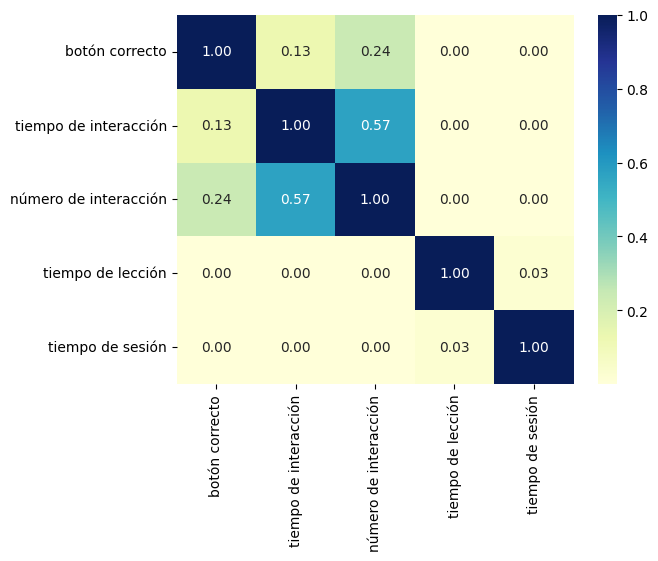

In [1251]:
Corr_Factors1=abs(matriz_corr)
Heat_Map=sns.heatmap(Corr_Factors1,cmap="YlGnBu",annot=True,fmt=".2f")
Heat_Map

## Proponer un modelo No lineal 

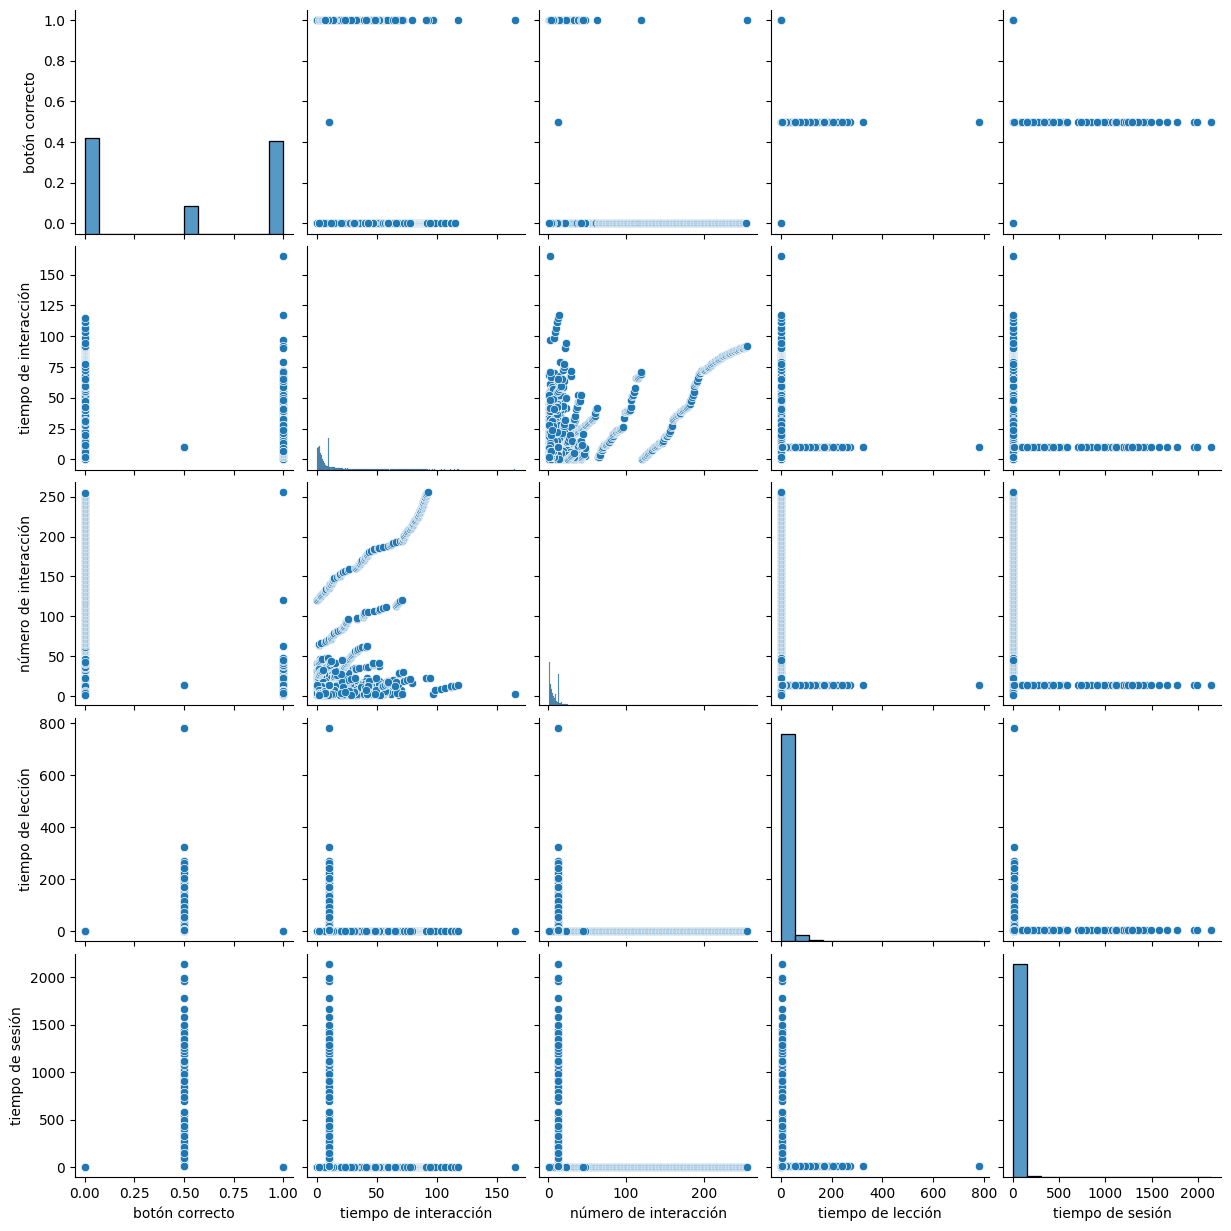

In [1252]:
sns.pairplot(data)

In [1253]:
Vars_Indep= data[['número de interacción']]
Var_Dep= data['botón correcto']

In [1254]:
x= Vars_Indep
y= Var_Dep

In [1255]:
#Modelo logaritmico
def  func1 (x, a, b, c):
     return a*np.log(x) + b

parametros1, covs= curve_fit(func1, data['número de interacción'], data['botón correcto'])
parametros1

C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\3409192805.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  parametros1, covs= curve_fit(func1, data['número de interacción'], data['botón correcto'])


array([-0.14282209,  0.75449846,  1.        ])

In [1256]:
# Predicciones
y_pred1 = func1(x, *parametros1)

In [1257]:
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1

,número de interacción
0,0.754498
1,0.655502
2,0.597592
3,0.556505
4,0.524635
...,...
5860,0.384909
5861,0.754498
5862,0.384909
5863,0.384909


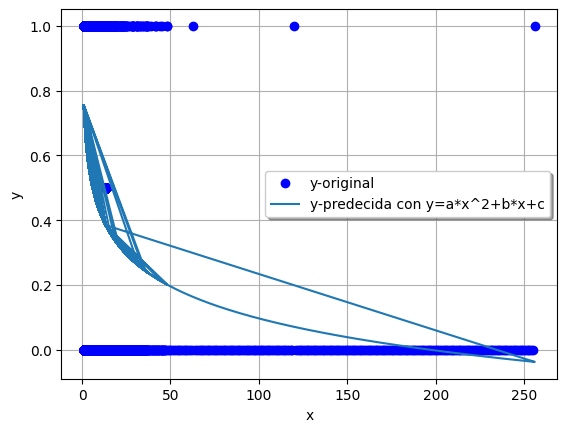

In [1258]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [1259]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1) 
R2_Modelo1 

0.11283896671081795

In [1260]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.3359151183123766)

## Generar un dataframe por cada “usuario”

In [1261]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
data["Usuario"]=data["Usuario"].str.replace("ALEIDA","1")
data["Usuario"]=data["Usuario"].str.replace("ADRIAN","2")
data["Usuario"]=data["Usuario"].str.replace("ARLETT","3")
data["Usuario"]=data["Usuario"].str.replace("ASHLEY","4")
data["Usuario"]=data["Usuario"].str.replace("AUSTIN","5")
data

,botón correcto,tiempo de interacción,número de interacción,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,Juego
0,1.0,5.399169,1.0,0.000000,0.000000,2,nicolas,9,4,1,Astro
1,0.0,1.283400,2.0,0.000000,0.000000,2,nicolas,9,1,1,Astro
2,1.0,2.700226,3.0,0.000000,0.000000,2,nicolas,9,2,1,Astro
3,0.0,3.050262,4.0,0.000000,0.000000,2,nicolas,9,2,1,Astro
4,0.0,4.750256,5.0,0.000000,0.000000,2,nicolas,9,2,1,Astro
...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,6.300000,332.240000,1,ESMERALDA,2,2,1,Astro
5861,0.0,2.135419,1.0,0.000000,0.000000,1,JOSE JAVIER,1,2,3,Astro
5862,0.5,10.000000,13.3,2.271806,12.400000,1,JOSE JAVIER,1,2,3,Astro
5863,0.5,10.000000,13.3,6.300000,6.478299,1,JOSE JAVIER,1,2,3,Astro


In [1262]:
data = data.apply(pd.to_numeric, errors="coerce")
data

,botón correcto,tiempo de interacción,número de interacción,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,Juego
0,1.0,5.399169,1.0,0.000000,0.000000,2,NaN,9,4,1,NaN
1,0.0,1.283400,2.0,0.000000,0.000000,2,NaN,9,1,1,NaN
2,1.0,2.700226,3.0,0.000000,0.000000,2,NaN,9,2,1,NaN
3,0.0,3.050262,4.0,0.000000,0.000000,2,NaN,9,2,1,NaN
4,0.0,4.750256,5.0,0.000000,0.000000,2,NaN,9,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,6.300000,332.240000,1,NaN,2,2,1,NaN
5861,0.0,2.135419,1.0,0.000000,0.000000,1,NaN,1,2,3,NaN
5862,0.5,10.000000,13.3,2.271806,12.400000,1,NaN,1,2,3,NaN
5863,0.5,10.000000,13.3,6.300000,6.478299,1,NaN,1,2,3,NaN


In [1263]:
data=data.fillna(round(data_cuanti.mean(),1))
data

,botón correcto,tiempo de interacción,número de interacción,tiempo de lección,tiempo de sesión,Administrador,Usuario,mini juego,color presionado,dificultad,Juego
0,1.0,5.399169,1.0,0.000000,0.000000,2,NaN,9,4,1,NaN
1,0.0,1.283400,2.0,0.000000,0.000000,2,NaN,9,1,1,NaN
2,1.0,2.700226,3.0,0.000000,0.000000,2,NaN,9,2,1,NaN
3,0.0,3.050262,4.0,0.000000,0.000000,2,NaN,9,2,1,NaN
4,0.0,4.750256,5.0,0.000000,0.000000,2,NaN,9,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5860,0.5,10.000000,13.3,6.300000,332.240000,1,NaN,2,2,1,NaN
5861,0.0,2.135419,1.0,0.000000,0.000000,1,NaN,1,2,3,NaN
5862,0.5,10.000000,13.3,2.271806,12.400000,1,NaN,1,2,3,NaN
5863,0.5,10.000000,13.3,6.300000,6.478299,1,NaN,1,2,3,NaN


In [1264]:
data=data.drop(["número de interacción"],axis=1)
data=data.drop(["tiempo de lección"],axis=1)
data=data.drop(["tiempo de sesión"],axis=1)
data=data.drop(["Administrador"],axis=1)
data=data.drop(["mini juego"],axis=1)
data=data.drop(["Juego"],axis=1)

In [1265]:
df_numeric = data.select_dtypes(include=["float64","int64","float","int"])
df_numeric

,botón correcto,tiempo de interacción,Usuario,color presionado,dificultad
0,1.0,5.399169,NaN,4,1
1,0.0,1.283400,NaN,1,1
2,1.0,2.700226,NaN,2,1
3,0.0,3.050262,NaN,2,1
4,0.0,4.750256,NaN,2,1
...,...,...,...,...,...
5860,0.5,10.000000,NaN,2,1
5861,0.0,2.135419,NaN,2,3
5862,0.5,10.000000,NaN,2,3
5863,0.5,10.000000,NaN,2,3


In [1266]:
aleida = 1
adrian = 2
austin = 3
ashley = 4
arlett = 5
ALEIDA = data[data["Usuario"] == aleida]
ADRIAN = data[data["Usuario"] == adrian]
AUSTIN = data[data["Usuario"] == austin]
ASHLEY = data[data["Usuario"] == ashley]
ARLETT = data[data["Usuario"] == arlett]


In [1267]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ALEIDA.corr()
Corr_Factors

,botón correcto,tiempo de interacción,Usuario,color presionado,dificultad
botón correcto,1.000000,0.031671,NaN,-0.022434,-0.308265
tiempo de interacción,0.031671,1.000000,NaN,-0.124226,-0.036661
Usuario,NaN,NaN,NaN,NaN,NaN
color presionado,-0.022434,-0.124226,NaN,1.000000,0.033010
dificultad,-0.308265,-0.036661,NaN,0.033010,1.000000


In [1268]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ADRIAN.corr()
Corr_Factors

,botón correcto,tiempo de interacción,Usuario,color presionado,dificultad
botón correcto,1.000000,-0.190970,NaN,0.027839,-0.061111
tiempo de interacción,-0.190970,1.000000,NaN,-0.027771,0.305132
Usuario,NaN,NaN,NaN,NaN,NaN
color presionado,0.027839,-0.027771,NaN,1.000000,0.049636
dificultad,-0.061111,0.305132,NaN,0.049636,1.000000


In [1269]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ARLETT.corr()
Corr_Factors

,botón correcto,tiempo de interacción,Usuario,color presionado,dificultad
botón correcto,1.000000,0.001153,NaN,0.014505,0.077679
tiempo de interacción,0.001153,1.000000,NaN,0.018008,-0.002165
Usuario,NaN,NaN,NaN,NaN,NaN
color presionado,0.014505,0.018008,NaN,1.000000,0.024752
dificultad,0.077679,-0.002165,NaN,0.024752,1.000000


In [1270]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ASHLEY.corr()
Corr_Factors

,botón correcto,tiempo de interacción,Usuario,color presionado,dificultad
botón correcto,1.000000,-0.057895,NaN,-0.094166,-0.096060
tiempo de interacción,-0.057895,1.000000,NaN,0.011746,0.211614
Usuario,NaN,NaN,NaN,NaN,NaN
color presionado,-0.094166,0.011746,NaN,1.000000,0.023590
dificultad,-0.096060,0.211614,NaN,0.023590,1.000000


In [1271]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=AUSTIN.corr()
Corr_Factors

,botón correcto,tiempo de interacción,Usuario,color presionado,dificultad
botón correcto,1.000000,-0.359681,NaN,0.213920,-0.320232
tiempo de interacción,-0.359681,1.000000,NaN,-0.518997,0.358348
Usuario,NaN,NaN,NaN,NaN,NaN
color presionado,0.213920,-0.518997,NaN,1.000000,-0.428363
dificultad,-0.320232,0.358348,NaN,-0.428363,1.000000


## Generar el heatmap de cada usuario

<Axes: >

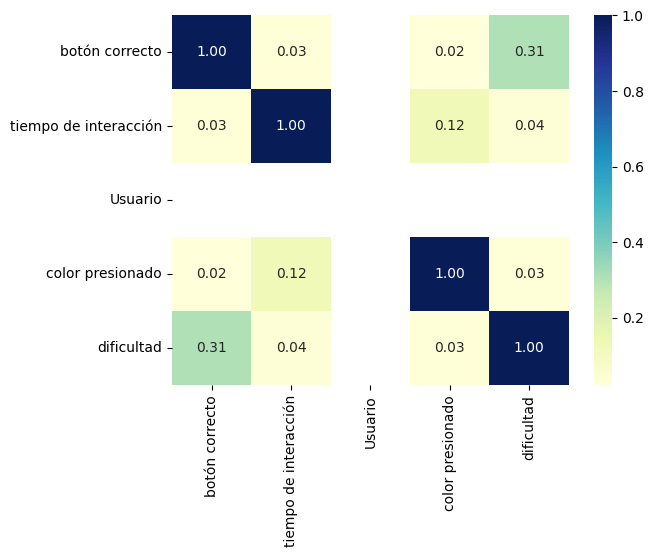

In [1272]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ALEIDA.corr()
Corr_Factors1=abs(Corr_Factors)
Heat_Map_ALEIDA=sns.heatmap(Corr_Factors1,cmap="YlGnBu",annot=True,fmt=".2f")
Heat_Map_ALEIDA

<Axes: >

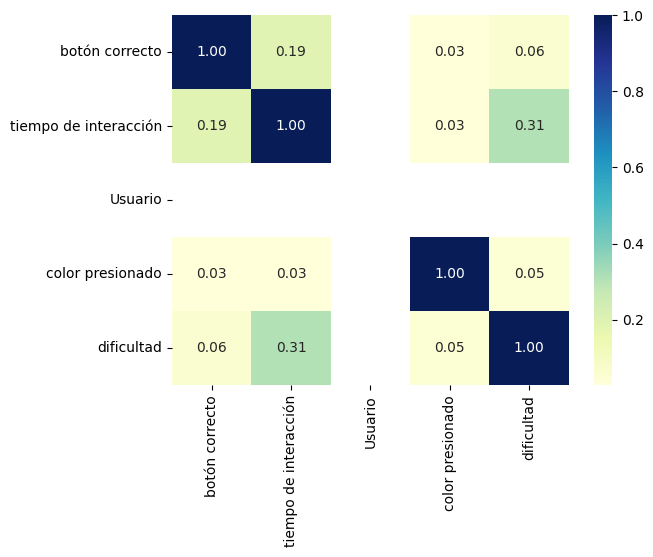

In [1273]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ADRIAN.corr()
Corr_Factors1=abs(Corr_Factors)
Heat_Map_ADRIAN=sns.heatmap(Corr_Factors1,cmap="YlGnBu",annot=True,fmt=".2f")
Heat_Map_ADRIAN

<Axes: >

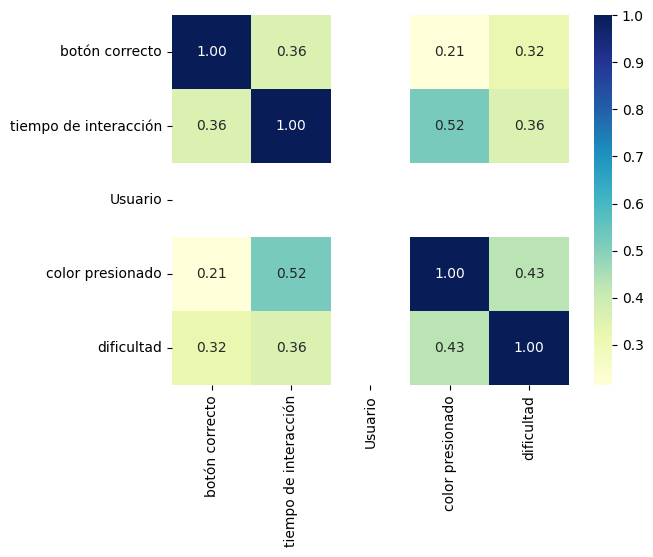

In [1274]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=AUSTIN.corr()
Corr_Factors1=abs(Corr_Factors)
Heat_Map_AUSTIN=sns.heatmap(Corr_Factors1,cmap="YlGnBu",annot=True,fmt=".2f")
Heat_Map_AUSTIN

<Axes: >

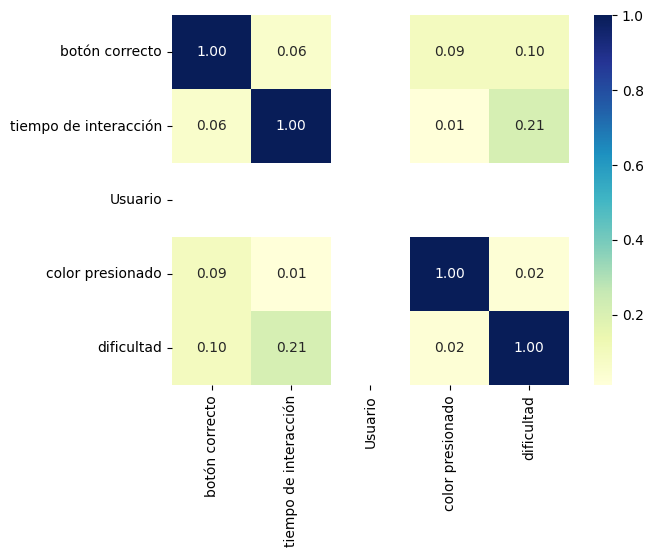

In [1275]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ASHLEY.corr()
Corr_Factors1=abs(Corr_Factors)
Heat_Map_ASHLEY=sns.heatmap(Corr_Factors1,cmap="YlGnBu",annot=True,fmt=".2f")
Heat_Map_ASHLEY

<Axes: >

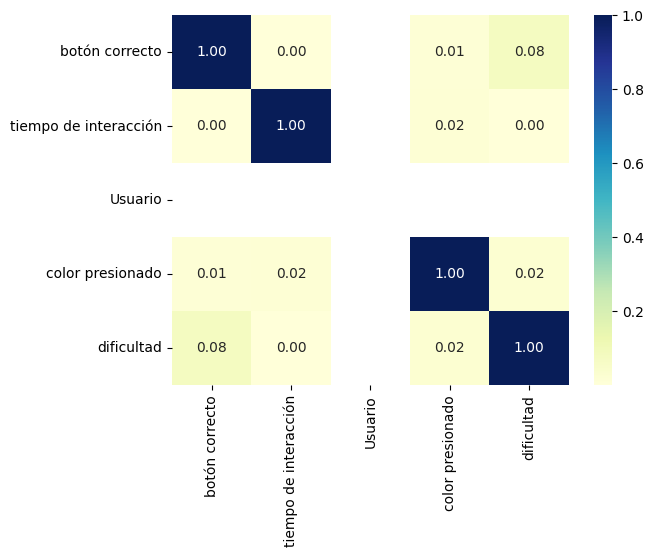

In [1285]:
#(ADRIAN, ALEIDA, ARLETT, ASHLEY, AUSTIN)
Corr_Factors=ARLETT.corr()
Corr_Factors1=abs(Corr_Factors)
Heat_Map_ARLETT=sns.heatmap(Corr_Factors1,cmap="YlGnBu",annot=True,fmt=".2f")
Heat_Map_ARLETT

## Proponer un modelo de regresión No Lineal que supere las correlaciones obtenidas en el heatmap de cada usuario

In [1277]:
Vars_Indep= data[['color presionado']]
Var_Dep= data['tiempo de interacción']
x= Vars_Indep
y= Var_Dep

In [1278]:
def  func1 (x, a, b, c):
     return a*np.log(x) + b

In [1279]:
import scipy.special as special
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [1280]:
parametros1, covs= curve_fit(func1, data['tiempo de interacción'], data['color presionado'])
parametros1

c:\Users\B_3mi\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\3856316967.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  parametros1, covs= curve_fit(func1, data['tiempo de interacción'], data['color presionado'])


array([1., 1., 1.])

In [1281]:
y_pred1 = func1(x, *parametros1)
y_pred1

,color presionado
0,2.386294
1,1.000000
2,1.693147
3,1.693147
4,1.693147
...,...
5860,1.693147
5861,1.693147
5862,1.693147
5863,1.693147


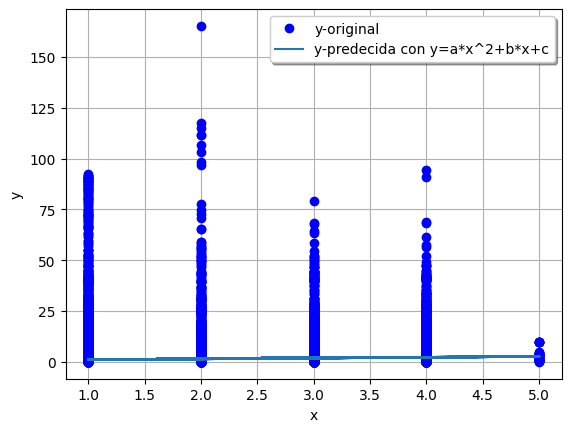

In [1282]:
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con y=a*x^2+b*x+c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [1283]:
R2_Modelo1 = r2_score(y, y_pred1) 
R2_Modelo1 

-0.35292616641920005

In [1284]:
R = np.sqrt(R2_Modelo1)
R

C:\Users\B_3mi\AppData\Local\Temp\ipykernel_12636\1366387113.py:1: RuntimeWarning: invalid value encountered in sqrt
  R = np.sqrt(R2_Modelo1)


np.float64(nan)